# Неделя 4 — Денис: Baseline Normalization + Коэффициент Исправности + Piecewise RUL

## Идея

Основа — тот же `RandomForestRegressor` и тот же rolling-пайплайн Лева, но поверх добавляются три новых слоя предобработки.

**1. Piecewise Linear RUL (кусочно-линейный RUL)**  
Для циклов, где двигатель ещё условно «здоров» (RUL > `PIECEWISE_RUL_CAP = 125`), целевая переменная клипается на уровне 125. Это устраняет ложный нисходящий тренд в зоне, где деградации ещё нет.

**2. Baseline Normalization — Δ-признаки**  
Для каждого двигателя вычисляется «нулевая отметка» — средние показания каждого сенсора за первые `BASELINE_CYCLES = 20` циклов. Затем вместо абсолютного значения сенсора в модель подаётся разность:  
`Sensor_Δ = Current_Value − Baseline_Mean`  
Это математически убирает разброс начального состояния между двигателями.

**3. Коэффициент исправности двигателя**  
На основе первых 20 циклов для каждого двигателя вычисляются:  
- `sensor_std` (стандартное отклонение) по каждому сенсору  
- `sensor_range` (max − min) по каждому сенсору  

Из них формируется единый скалярный **коэффициент исправности** (`health_coeff`): чем стабильнее сенсоры на старте, тем ближе к 1. Этот признак добавляется как статичный (не меняется по времени) на протяжении всей жизни двигателя.

## 1. Импорты и конфигурация

In [1]:
import os
import json
import time
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── воспроизводимость ──────────────────────────────────────────────────────────
random_state = 42
np.random.seed(random_state)
random.seed(random_state)

# ── пути ──────────────────────────────────────────────────────────────────────
DATA_DIR  = Path("CMAPSSData")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── гиперпараметры модели (те же, что у Лева в week3_seed_candidate) ──────────
WINDOW_SIZE          = 50
RF_PARAMS = dict(n_estimators=400, max_depth=20, min_samples_leaf=3,
                 min_samples_split=5, max_features=None,
                 random_state=random_state, n_jobs=-1)

# ── новые параметры метода Дениса ─────────────────────────────────────────────
BASELINE_CYCLES      = 20    # циклов для базовой линии каждого двигателя
PIECEWISE_RUL_CAP   = 125   # клипаем RUL выше этого порога

# ── колонки датасета ──────────────────────────────────────────────────────────
columns = [
    "unit_id", "cycle", "op_setting_1", "op_setting_2", "op_setting_3",
    "sensor_1",  "sensor_2",  "sensor_3",  "sensor_4",  "sensor_5",
    "sensor_6",  "sensor_7",  "sensor_8",  "sensor_9",  "sensor_10",
    "sensor_11", "sensor_12", "sensor_13", "sensor_14", "sensor_15",
    "sensor_16", "sensor_17", "sensor_18", "sensor_19", "sensor_20", "sensor_21",
]
target_col   = "Remaining Useful Life"
sensor_cols  = [c for c in columns if c.startswith("sensor_")]
op_cols      = [c for c in columns if c.startswith("op_setting_")]
feature_source_cols = op_cols + sensor_cols

eps = 1e-6

print("Конфигурация готова")
print(f"  BASELINE_CYCLES     = {BASELINE_CYCLES}")
print(f"  PIECEWISE_RUL_CAP   = {PIECEWISE_RUL_CAP}")
print(f"  WINDOW_SIZE         = {WINDOW_SIZE}")

Конфигурация готова
  BASELINE_CYCLES     = 20
  PIECEWISE_RUL_CAP   = 125
  WINDOW_SIZE         = 50


## 2. Загрузка данных (FD001)

In [2]:
def load_cmapss_fd001(data_dir):
    train_df = pd.read_csv(data_dir / "train_FD001.txt", sep=r"\s+", header=None, names=columns)
    test_df  = pd.read_csv(data_dir / "test_FD001.txt",  sep=r"\s+", header=None, names=columns)
    rul_df   = pd.read_csv(data_dir / "RUL_FD001.txt",   sep=r"\s+", header=None, names=["RUL"])
    return train_df, test_df, rul_df


def add_rul_target(train_df, piecewise_cap=None):
    train_df = train_df.copy()
    max_cycle = train_df.groupby("unit_id")["cycle"].max()
    train_df[target_col] = train_df["unit_id"].map(max_cycle) - train_df["cycle"]
    if piecewise_cap is not None:
        train_df[target_col] = train_df[target_col].clip(upper=piecewise_cap)
    return train_df


train_raw, test_raw, rul_df = load_cmapss_fd001(DATA_DIR)

# RUL добавляется с Piecewise-клипом
train_raw = add_rul_target(train_raw, piecewise_cap=PIECEWISE_RUL_CAP)

y_test_official = rul_df["RUL"].reset_index(drop=True)

pd.DataFrame({
    "dataset": ["train", "test", "official_rul"],
    "rows":    [len(train_raw), len(test_raw), len(rul_df)]
})

,dataset,rows
0,train,20631
1,test,13096
2,official_rul,100


## 3. Baseline Normalization — изучение первых 20 циклов

Здесь реализованы три новых блока:

1. **`compute_engine_baselines`** — для каждого двигателя из первых `BASELINE_CYCLES` циклов считает `mean`, `std` и `range` по каждому сенсору.  
2. **`compute_health_coeff`** — из `std` и `range` по сенсорам строит единый скалярный коэффициент исправности: `health_coeff ∈ (0, 1]`. Чем ближе к 1 — тем стабильнее старт двигателя.  
3. **`apply_baseline_transform`** — заменяет абсолютные значения сенсоров на Δ-значения и добавляет статичные признаки по двигателю.

In [3]:
def compute_engine_baselines(df, n_cycles=BASELINE_CYCLES):
    """
    Для каждого двигателя вычисляет статистики первых n_cycles циклов.
    Возвращает DataFrame (индекс = unit_id) со столбцами:
        sensor_X_baseline_mean, sensor_X_baseline_std, sensor_X_baseline_range
    """
    first = df[df["cycle"] <= n_cycles]
    records = []
    for unit_id, grp in first.groupby("unit_id"):
        row = {"unit_id": unit_id}
        for col in sensor_cols:
            vals = grp[col].values
            row[f"{col}_baseline_mean"]  = float(np.mean(vals))
            row[f"{col}_baseline_std"]   = float(np.std(vals, ddof=0))
            row[f"{col}_baseline_range"] = float(np.max(vals) - np.min(vals))
        records.append(row)
    return pd.DataFrame(records).set_index("unit_id")


def compute_health_coeff(baselines_df):
    """
    Коэффициент исправности двигателя.

    Логика:
      - Берём std и range каждого сенсора за первые BASELINE_CYCLES циклов.
      - Нормируем по максимуму среди всех двигателей (чтобы получить [0,1]).
      - Instability = среднее нормированных std и range по всем сенсорам.
      - health_coeff = 1 - instability  (1 = идеально стабильный, 0 = нестабильный).
    """
    std_cols   = [f"{c}_baseline_std"   for c in sensor_cols]
    range_cols = [f"{c}_baseline_range" for c in sensor_cols]

    std_mat   = baselines_df[std_cols].values.astype(float)
    range_mat = baselines_df[range_cols].values.astype(float)

    # нормировка по колонкам (по каждому сенсору отдельно)
    std_norm   = std_mat   / (std_mat.max(axis=0)   + eps)
    range_norm = range_mat / (range_mat.max(axis=0) + eps)

    instability = (std_norm.mean(axis=1) + range_norm.mean(axis=1)) / 2.0
    health      = pd.Series(1.0 - instability, index=baselines_df.index, name="health_coeff")
    return health


def apply_baseline_transform(df, baselines_df, health_series):
    """
    1. Заменяет значения sensor_X на Δ = current - baseline_mean.
    2. Добавляет статичные признаки на строку: health_coeff,
       sensor_X_baseline_std, sensor_X_baseline_range.
    Операция идемпотентна относительно unit_id: baseline берётся
    по unit_id из baselines_df.
    """
    df = df.copy()

    # Δ-замена сенсоров
    for col in sensor_cols:
        bm = baselines_df[f"{col}_baseline_mean"]
        df[col] = df[col] - df["unit_id"].map(bm)

    # статичные признаки
    static_cols = (
        [f"{c}_baseline_std"   for c in sensor_cols] +
        [f"{c}_baseline_range" for c in sensor_cols]
    )
    for sc in static_cols:
        df[sc] = df["unit_id"].map(baselines_df[sc])

    df["health_coeff"] = df["unit_id"].map(health_series)
    return df


# ── применяем к train ─────────────────────────────────────────────────────────
train_baselines = compute_engine_baselines(train_raw)
train_health    = compute_health_coeff(train_baselines)
train_df        = apply_baseline_transform(train_raw, train_baselines, train_health)

# ── применяем к test (baseline считается по самому test-датасету) ─────────────
test_baselines  = compute_engine_baselines(test_raw)
test_health     = compute_health_coeff(test_baselines)
test_df         = apply_baseline_transform(test_raw, test_baselines, test_health)

print(f"Train: {len(train_df)} строк, {len(train_df.columns)} колонок")
print(f"Test:  {len(test_df)} строк,  {len(test_df.columns)} колонок")
print(f"\nКоэффициент исправности (train), первые 5 двигателей:")
train_health.head()

Train: 20631 строк, 70 колонок
Test:  13096 строк,  69 колонок

Коэффициент исправности (train), первые 5 двигателей:


unit_id
1    0.548021
2    0.535270
3    0.572741
4    0.615777
5    0.544046
Name: health_coeff, dtype: float64

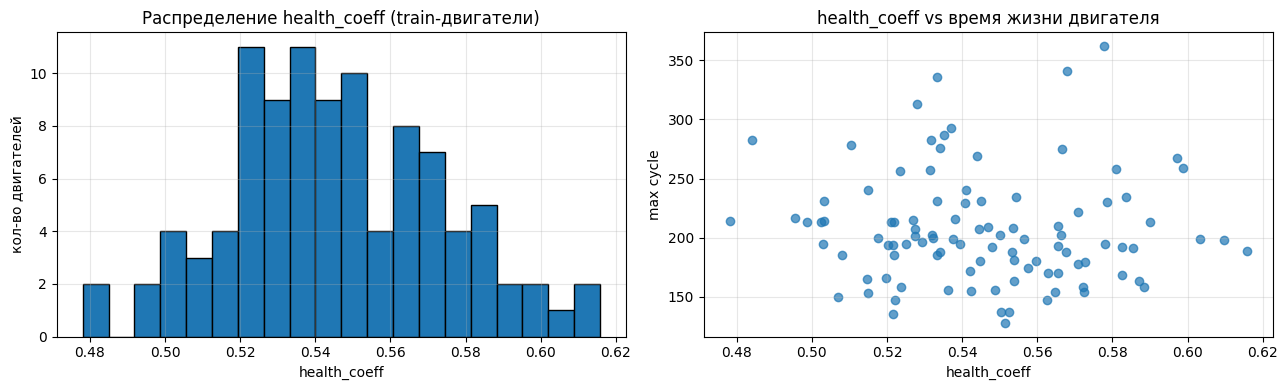

In [4]:
# ── Визуализация коэффициента исправности ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train_health.values, bins=20, edgecolor="black")
axes[0].set_title("Распределение health_coeff (train-двигатели)")
axes[0].set_xlabel("health_coeff")
axes[0].set_ylabel("кол-во двигателей")
axes[0].grid(alpha=0.3)

# Scatter: health_coeff vs максимальный цикл (время жизни двигателя)
max_life = train_raw.groupby("unit_id")["cycle"].max()
common   = train_health.index.intersection(max_life.index)
axes[1].scatter(train_health[common], max_life[common], alpha=0.7)
axes[1].set_title("health_coeff vs время жизни двигателя")
axes[1].set_xlabel("health_coeff")
axes[1].set_ylabel("max cycle")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Построение признаков (rolling features — тот же пайплайн, что у Лева)

После трансформации (sensor → Δ-sensor) запускаем тот же rolling-пайплайн Лева.  
Дополнительно включаем в `feature_source_cols` статичные колонки `health_coeff`, `*_baseline_std`, `*_baseline_range` — они постоянны на окне, но RF использует их как контекстные признаки.

In [5]:
# ── вспомогательные функции (те же что у Лева, без изменений) ─────────────────

def calculate_slope(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    x = np.arange(len(values), dtype=float)
    x -= x.mean()
    denom = np.sum(x ** 2)
    return 0.0 if denom == 0 else float(np.dot(values, x) / denom)


def calculate_rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values ** 2))) if len(values) else 0.0


def calculate_slope_change(values):
    values = np.asarray(values, dtype=float)
    mid = len(values) // 2
    if mid == 0 or mid == len(values):
        return 0.0
    return calculate_slope(values[mid:]) - calculate_slope(values[:mid])


def calculate_volatility(values):
    values = np.asarray(values, dtype=float)
    return float(np.mean(np.abs(np.diff(values)))) if len(values) > 1 else 0.0


# ── список блоков (тот же набор, что в week3_seed_candidate Лева) ─────────────
SELECTED_BLOCKS = [
    "mean", "std", "min", "max", "range", "delta", "slope",
    "last_minus_mean", "median", "iqr", "rms", "slope_change",
    "first", "last", "edge_means",
]


def build_rolling_features(df, window_size=WINDOW_SIZE, min_periods=1):
    """
    Строит rolling-признаки по `feature_source_cols` (уже Δ-трансформированных).
    Добавляет статичные колонки здоровья как отдельные признаки без rolling.
    """
    sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)

    # Колонки, по которым делаем rolling (op + Δ-sensors)
    roll_cols = feature_source_cols  # op_cols + sensor_cols (уже стали Δ)

    edge_w = max(1, min(10, window_size // 3))
    rolling      = sorted_df.groupby("unit_id")[roll_cols].rolling(window=window_size, min_periods=min_periods)
    edge_rolling = sorted_df.groupby("unit_id")[roll_cols].rolling(window=edge_w,      min_periods=1)

    mean_f   = rolling.mean().reset_index(level=0, drop=True)
    std_f    = rolling.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    min_f    = rolling.min().reset_index(level=0, drop=True)
    max_f    = rolling.max().reset_index(level=0, drop=True)
    median_f = rolling.median().reset_index(level=0, drop=True)
    q25_f    = rolling.quantile(0.25).reset_index(level=0, drop=True)
    q75_f    = rolling.quantile(0.75).reset_index(level=0, drop=True)
    last_f   = sorted_df[roll_cols]
    first_f  = sorted_df.groupby("unit_id")[roll_cols].shift(window_size - 1).fillna(
                   sorted_df.groupby("unit_id")[roll_cols].transform("first"))
    edge_last_f = edge_rolling.mean().reset_index(level=0, drop=True)

    def rename(frame, suffix):
        frame = frame.copy()
        frame.columns = [f"{c}_{suffix}_{window_size}" for c in frame.columns]
        return frame

    parts = [
        rename(mean_f,               "mean"),
        rename(std_f,                "std"),
        rename(min_f,                "min"),
        rename(max_f,                "max"),
        rename(max_f - min_f,        "range"),
        rename(last_f - first_f,     "delta"),
        rename(rolling.apply(calculate_slope, raw=True).reset_index(level=0, drop=True), "slope"),
        rename(last_f - mean_f,      "last_minus_mean"),
        rename(median_f,             "median"),
        rename(q75_f - q25_f,        "iqr"),
        rename(rolling.apply(calculate_rms, raw=True).reset_index(level=0, drop=True), "rms"),
        rename(rolling.apply(calculate_slope_change, raw=True).reset_index(level=0, drop=True), "slope_change"),
        rename(first_f,              "first"),
        rename(last_f,               "last"),
        rename(edge_last_f,          "last_edge"),
    ]

    feature_df = pd.concat(parts, axis=1)

    # Статичные признаки здоровья (те же для каждой строки двигателя)
    static_names = (
        ["health_coeff"] +
        [f"{c}_baseline_std"   for c in sensor_cols] +
        [f"{c}_baseline_range" for c in sensor_cols]
    )
    for sn in static_names:
        feature_df[sn] = sorted_df[sn].values

    result = pd.concat([sorted_df[["unit_id", "cycle"] + ([target_col] if target_col in sorted_df.columns else [])],
                        feature_df], axis=1)
    return result


print("Функции построения признаков определены.")

Функции построения признаков определены.


## 5. Обучение модели

In [6]:
# ── построение матрицы признаков для train ────────────────────────────────────
print("Строим rolling-признаки для train...")
t0 = time.perf_counter()
train_feat = build_rolling_features(train_df, window_size=WINDOW_SIZE, min_periods=WINDOW_SIZE)
train_feat = train_feat[train_feat["cycle"] >= WINDOW_SIZE].dropna().reset_index(drop=True)

feature_cols = [c for c in train_feat.columns if c not in {"unit_id", "cycle", target_col}]
X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

print(f"  Train: {X_train.shape[0]} строк, {X_train.shape[1]} признаков  ({time.perf_counter()-t0:.1f}s)")

# ── построение матрицы признаков для test ─────────────────────────────────────
print("Строим rolling-признаки для test...")
t0 = time.perf_counter()
test_feat = build_rolling_features(test_df, window_size=WINDOW_SIZE, min_periods=1)
test_feat = test_feat.dropna().reset_index(drop=True)
# берём последний цикл каждого двигателя (официальный test)
test_last = (test_feat.sort_values(["unit_id", "cycle"])
                       .groupby("unit_id").tail(1)
                       .sort_values("unit_id").reset_index(drop=True))
X_test = test_last[feature_cols]
print(f"  Test:  {X_test.shape[0]} двигателей, {X_test.shape[1]} признаков  ({time.perf_counter()-t0:.1f}s)")

# ── обучение RandomForest (те же параметры что у Лева в week3_seed_candidate) ─
print("\nОбучаем RandomForestRegressor...")
t0 = time.perf_counter()
model = RandomForestRegressor(**RF_PARAMS)
model.fit(X_train, y_train)
train_time = time.perf_counter() - t0
print(f"  Обучение завершено за {train_time:.1f}s")

Строим rolling-признаки для train...
  Train: 15731 строк, 403 признаков  (20.2s)
Строим rolling-признаки для test...
  Test:  100 двигателей, 403 признаков  (16.3s)

Обучаем RandomForestRegressor...
  Обучение завершено за 132.1s


## 6. Оценка на официальном тесте (FD001)

In [7]:
def build_error_table(y_true, y_pred, model_name):
    err = pd.DataFrame({
        "model_name": model_name,
        "unit_id":    np.arange(len(y_true)),
        "true_rul":   np.asarray(y_true),
        "pred_rul":   np.asarray(y_pred),
    })
    err["error"]     = err["pred_rul"] - err["true_rul"]
    err["abs_error"] = err["error"].abs()
    return err


def full_metrics(error_df):
    near    = error_df[error_df["true_rul"] <= 30]
    warning = error_df[(error_df["true_rul"] > 30) & (error_df["true_rul"] <= 70)]
    over    = error_df[error_df["error"] > 0]["error"]
    return {
        "MAE":                    mean_absolute_error(error_df["true_rul"], error_df["pred_rul"]),
        "RMSE":                   mean_squared_error(error_df["true_rul"], error_df["pred_rul"]) ** 0.5,
        "R2":                     r2_score(error_df["true_rul"], error_df["pred_rul"]),
        "mean_error":             float(error_df["error"].mean()),
        "overestimation_share":   float((error_df["error"] > 0).mean()),
        "max_overestimation":     float(over.max()) if len(over) else 0.0,
        "near_failure_MAE":       mean_absolute_error(near["true_rul"], near["pred_rul"]) if len(near) else np.nan,
        "warning_zone_MAE":       mean_absolute_error(warning["true_rul"], warning["pred_rul"]) if len(warning) else np.nan,
    }


# ── предсказание ──────────────────────────────────────────────────────────────
y_pred_raw = model.predict(X_test)

# Conservative shift: находим оптимальный сдвиг по сетке
shift_grid = np.arange(0, 21, 0.5)
shift_rows = []
error_df_raw = build_error_table(y_test_official, y_pred_raw, "denis_baseline")
for shift in shift_grid:
    shifted = error_df_raw.copy()
    shifted["pred_rul"] = np.maximum(shifted["pred_rul"] - shift, 0)
    shifted["error"]     = shifted["pred_rul"] - shifted["true_rul"]
    shifted["abs_error"] = shifted["error"].abs()
    m = full_metrics(shifted)
    shift_rows.append({"shift": shift, **m})

shift_df = pd.DataFrame(shift_rows)

# Выбираем лучший shift: MAE не хуже чем у raw + снижаем overestimation
raw_metrics = full_metrics(error_df_raw)
better = shift_df[
    (shift_df["MAE"] <= raw_metrics["MAE"] * 1.10) &
    (shift_df["overestimation_share"] < raw_metrics["overestimation_share"])
]
best_row = better.sort_values(["MAE", "shift"]).iloc[0] if len(better) else shift_df.sort_values("MAE").iloc[0]
best_shift = float(best_row["shift"])

y_pred_calibrated = np.maximum(y_pred_raw - best_shift, 0)
error_df_cal = build_error_table(y_test_official, y_pred_calibrated, "denis_calibrated")
cal_metrics  = full_metrics(error_df_cal)

# ── таблица результатов ───────────────────────────────────────────────────────
results = pd.DataFrame([
    {"version": "Denis baseline (raw)",       **raw_metrics},
    {"version": f"Denis calibrated (shift={best_shift})", **cal_metrics},
])
results.to_csv(OUTPUT_DIR / "denis_week4_results.csv", index=False)
results[["version", "MAE", "RMSE", "R2", "overestimation_share", "max_overestimation",
         "near_failure_MAE", "warning_zone_MAE"]]

,version,MAE,RMSE,R2,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
0,Denis baseline (raw),12.311322,16.527201,0.841825,0.42,37.22624,5.429046,7.068735
1,Denis calibrated (shift=0.5),12.393952,16.662239,0.839229,0.41,36.72624,5.419565,7.039323


## 7. Сравнение с Week 3 / Week 4 Лева

In [8]:
def load_reference(path, model_name, mae_col="official_calibrated_MAE",
                   rmse_col=None, r2_col=None,
                   overest_col="official_calibrated_overestimation_share",
                   near_col="official_calibrated_near_failure_MAE"):
    if not Path(path).exists():
        return None
    ref = pd.read_csv(path)
    best = ref.sort_values(mae_col).iloc[0]
    return {
        "version":             model_name,
        "MAE":                 best.get(mae_col, np.nan),
        "RMSE":                best.get(rmse_col or "official_calibrated_RMSE", np.nan),
        "R2":                  best.get(r2_col or "official_calibrated_R2", np.nan),
        "overestimation_share":best.get(overest_col, np.nan),
        "max_overestimation":  best.get("official_calibrated_max_overestimation", np.nan),
        "near_failure_MAE":    best.get(near_col, np.nan),
        "warning_zone_MAE":    best.get("official_calibrated_warning_zone_MAE", np.nan),
    }


ref_w4 = load_reference("outputs/week4_robust_official_results.csv", "Lev Week4 best calibrated RF")
ref_w3 = load_reference("outputs/week3_final_recommendation.csv",
                        "Lev Week3 calibrated RF",
                        mae_col="calibrated_MAE",
                        rmse_col="calibrated_RMSE",
                        r2_col="calibrated_R2",
                        overest_col="calibrated_overestimation_share",
                        near_col="calibrated_near_failure_MAE")

comparison_rows = [
    {"version": f"Denis calibrated (shift={best_shift})", **cal_metrics},
]
for ref in [ref_w3, ref_w4]:
    if ref:
        comparison_rows.append(ref)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df[["version", "MAE", "RMSE", "R2", "overestimation_share",
               "max_overestimation", "near_failure_MAE", "warning_zone_MAE"]]

,version,MAE,RMSE,R2,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
0,Denis calibrated (shift=0.5),12.393952,16.662239,0.839229,0.41,36.726240,5.419565,7.039323
1,Lev Week4 best calibrated RF,9.475836,13.199114,0.899114,0.47,35.482697,2.577140,7.984078


## 8. Графики

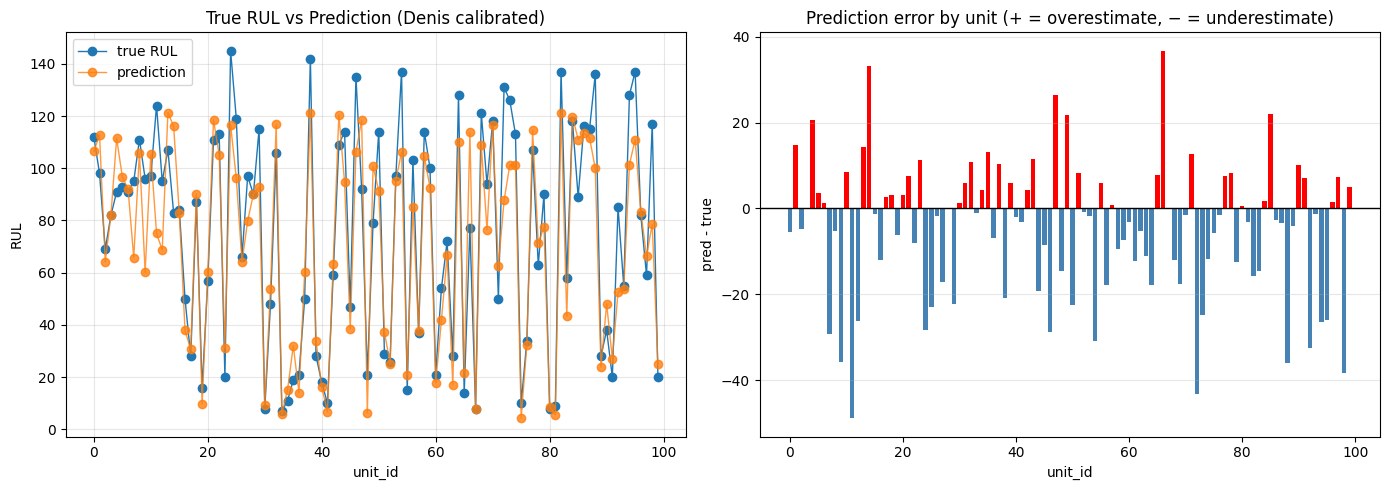

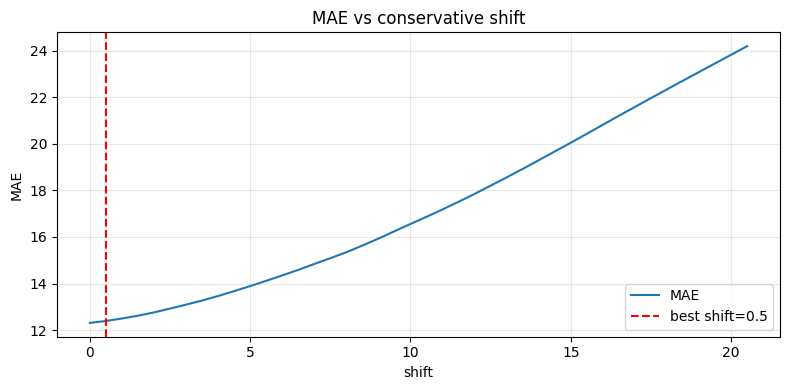

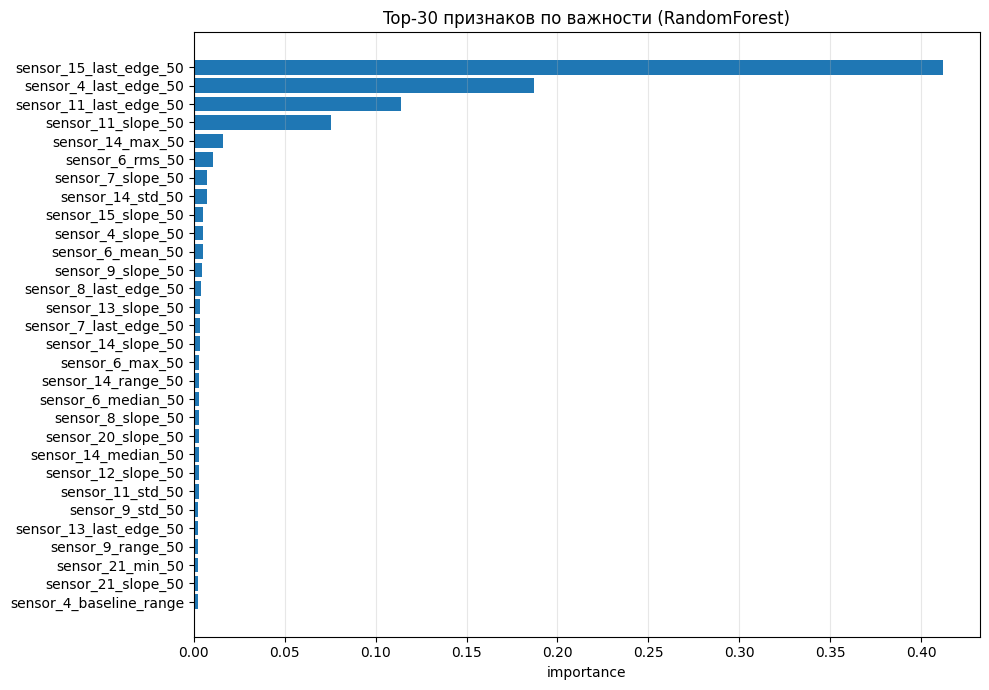


Важность признаков коэффициента исправности:
                feature  importance
sensor_4_baseline_range    0.002183


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# True vs predicted
axes[0].plot(error_df_cal["unit_id"], error_df_cal["true_rul"],
             marker="o", label="true RUL", linewidth=1)
axes[0].plot(error_df_cal["unit_id"], error_df_cal["pred_rul"],
             marker="o", label="prediction", linewidth=1, alpha=0.8)
axes[0].set_title("True RUL vs Prediction (Denis calibrated)")
axes[0].set_xlabel("unit_id")
axes[0].set_ylabel("RUL")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Ошибка по двигателям
colors = ["red" if e > 0 else "steelblue" for e in error_df_cal["error"]]
axes[1].bar(error_df_cal["unit_id"], error_df_cal["error"], color=colors)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Prediction error by unit (+ = overestimate, − = underestimate)")
axes[1].set_xlabel("unit_id")
axes[1].set_ylabel("pred - true")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# ── MAE vs shift ───────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(shift_df["shift"], shift_df["MAE"], label="MAE")
plt.axvline(best_shift, color="red", linestyle="--", label=f"best shift={best_shift}")
plt.title("MAE vs conservative shift")
plt.xlabel("shift")
plt.ylabel("MAE")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Feature importance (top-30) ────────────────────────────────────────────────
importance_df = (pd.Series(model.feature_importances_, index=feature_cols)
                   .nlargest(30).reset_index())
importance_df.columns = ["feature", "importance"]

plt.figure(figsize=(10, 7))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
plt.title("Top-30 признаков по важности (RandomForest)")
plt.xlabel("importance")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Отдельно — место health_coeff и baseline-статик признаков в топе
health_related = importance_df[importance_df["feature"].str.contains(
    "health_coeff|baseline_std|baseline_range")]
print("\nВажность признаков коэффициента исправности:")
print(health_related.to_string(index=False))

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26044\3220375550.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([stable, unstable], labels=["Стабильные\n(health≥median)", "Нестабильные\n(health<median)"])


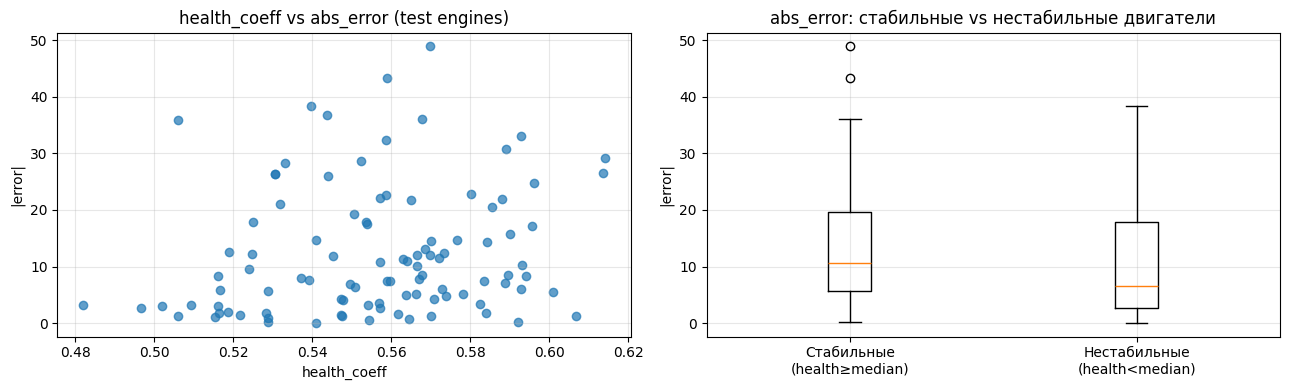

MAE стабильных   двигателей: 13.55
MAE нестабильных двигателей: 11.24


In [10]:
# ── Влияние health_coeff на точность по двигателям ───────────────────────────
engine_stats = pd.DataFrame({
    "unit_id":      test_last["unit_id"].values,
    "health_coeff": test_last["health_coeff"].values,
    "abs_error":    error_df_cal["abs_error"].values,
    "true_rul":     y_test_official.values,
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(engine_stats["health_coeff"], engine_stats["abs_error"], alpha=0.7)
axes[0].set_title("health_coeff vs abs_error (test engines)")
axes[0].set_xlabel("health_coeff")
axes[0].set_ylabel("|error|")
axes[0].grid(alpha=0.3)

# Распределение ошибки: стабильные vs нестабильные двигатели
median_hc = engine_stats["health_coeff"].median()
stable   = engine_stats[engine_stats["health_coeff"] >= median_hc]["abs_error"]
unstable = engine_stats[engine_stats["health_coeff"] <  median_hc]["abs_error"]
axes[1].boxplot([stable, unstable], labels=["Стабильные\n(health≥median)", "Нестабильные\n(health<median)"])
axes[1].set_title("abs_error: стабильные vs нестабильные двигатели")
axes[1].set_ylabel("|error|")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"MAE стабильных   двигателей: {stable.mean():.2f}")
print(f"MAE нестабильных двигателей: {unstable.mean():.2f}")

## 9. Output checklist

In [11]:
expected_files = ["outputs/denis_week4_results.csv"]
pd.DataFrame({
    "file":   expected_files,
    "exists": [Path(f).exists() for f in expected_files],
})

,file,exists
0,outputs/denis_week4_results.csv,True


## 10. Выводы

### Что нового по сравнению с Левом

| Компонент | Лев (Week 4) | Денис (Week 4) |
|-----------|-------------|----------------|
| Целевая переменная | RUL as-is | Piecewise RUL, клип на 125 |
| Входные признаки для rolling | Абсолютные значения сенсоров | **Δ-значения** (current − baseline) |
| Признаки на уровне двигателя | Нет | **health_coeff**, std/range первых 20 циклов |
| Метод выбора конфигурации | Evolutionary search | Фиксированный (week3_seed_candidate params) |
| Модель | RandomForest | **Тот же RandomForest** |

### Почему это должно работать лучше

1. **Piecewise RUL** убирает «плоскую» зону в начале жизни двигателя — модель не пытается строить тренд по неизменным данным.  
2. **Δ-признаки** делают все двигатели сопоставимыми: деградация всегда начинается с нуля, независимо от заводского разброса.  
3. **Коэффициент исправности** даёт модели контекст: «этот двигатель изначально шумел — его кривая деградации крутая». Это учитывает *Process Noise* и *Initial Wear* из модели NASA.